In [104]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
import matplotlib.pyplot as plt

In [105]:
# 1. Load the preprocessed dataset
df = pd.read_csv('../data/interim/olist_ml_processed_dataset.csv')


# 3. Separate the features (X) and the target variable (y)
X = df.drop(columns=['delivery_delay_days',"delivery_status"]).values.astype('float32')
y = df['delivery_delay_days'].values.astype('float32').reshape(-1, 1)

# 4. Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Convert numpy arrays into PyTorch Tensors and create TensorDatasets
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

# 6. Create DataLoaders with a batch size of 256
batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Verify the dimensions
print(f"Number of input features: {X.shape[1]}")
print(f"Training samples: {len(X_train)} ({len(train_loader)} batches)")
print(f"Testing samples: {len(X_test)} ({len(test_loader)} batches)")

Number of input features: 7
Training samples: 69223 (271 batches)
Testing samples: 17306 (68 batches)


In [106]:
# Inspect a single batch
features_batch, targets_batch = next(iter(train_loader))
print("Features batch shape:", features_batch.shape)  # Expected: torch.Size([128, 7])
print("Targets batch shape:", targets_batch.shape)    # Expected: torch.Size([128, 1])

Features batch shape: torch.Size([256, 7])
Targets batch shape: torch.Size([256, 1])


In [ ]:
class DeliveryDelayNN(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.2):
        super(DeliveryDelayNN, self).__init__()
        self.hidden_layers = nn.ModuleList([
            nn.Linear(input_dim, 512),
            nn.Linear(512, 256),
            nn.Linear(256, 128),
            nn.Linear(128, 64),
            nn.Linear(64, 32),
            nn.Linear(32, 16),
        ])
        self.gelu = nn.GELU()
        self.dropout = nn.Dropout(p=dropout_rate)
        self.output_layer = nn.Linear(16, 1)
        self._init_weights()

    def _init_weights(self):
        for layer in self.hidden_layers:
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)
        nn.init.xavier_uniform_(self.output_layer.weight)
        nn.init.zeros_(self.output_layer.bias)

    def forward(self, x):
        for layer in self.hidden_layers:
            x = layer(x)
            x = self.gelu(x)
            x = self.dropout(x)
        return self.output_layer(x)

# 1. Define input dimensions based on the 7 features from our processed dataset
input_dim = 7

# 2. Instantiate the network
model = DeliveryDelayNN(input_dim=input_dim)

# 3. Define the Adam optimizer
# A standard starting learning rate is 0.001, which can be tuned later
optimizer = optim.Adam(model.parameters(), lr=0.0008)

# 4. Define Loss Function (Mean Squared Error is standard for regression)
criterion = nn.MSELoss()

# Print out the structured network architecture
print(model)

DeliveryDelayNN(
  (hidden_layers): ModuleList(
    (0): Linear(in_features=7, out_features=512, bias=True)
    (1): Linear(in_features=512, out_features=256, bias=True)
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): Linear(in_features=32, out_features=16, bias=True)
  )
  (gelu): GELU(approximate='none')
  (dropout): Dropout(p=0.2, inplace=False)
  (output_layer): Linear(in_features=16, out_features=1, bias=True)
)


Epoch 01/100 | Train MSE: 60.5122 - Test MSE: 33.8420 | Train Bin Acc: 79.65% - Test Bin Acc: 88.50%
Epoch 02/100 | Train MSE: 41.9563 - Test MSE: 33.5213 | Train Bin Acc: 87.86% - Test Bin Acc: 89.01%
Epoch 03/100 | Train MSE: 39.9585 - Test MSE: 33.1703 | Train Bin Acc: 88.07% - Test Bin Acc: 89.00%
Epoch 04/100 | Train MSE: 39.2590 - Test MSE: 33.0883 | Train Bin Acc: 88.30% - Test Bin Acc: 88.82%
Epoch 05/100 | Train MSE: 38.8193 - Test MSE: 33.1341 | Train Bin Acc: 88.08% - Test Bin Acc: 89.03%
Epoch 06/100 | Train MSE: 38.3220 - Test MSE: 32.7167 | Train Bin Acc: 88.17% - Test Bin Acc: 89.07%
Epoch 07/100 | Train MSE: 38.0067 - Test MSE: 32.7700 | Train Bin Acc: 88.12% - Test Bin Acc: 89.04%
Epoch 08/100 | Train MSE: 37.7673 - Test MSE: 32.7399 | Train Bin Acc: 88.17% - Test Bin Acc: 88.96%
Epoch 09/100 | Train MSE: 37.5367 - Test MSE: 33.2649 | Train Bin Acc: 88.25% - Test Bin Acc: 89.12%
Epoch 10/100 | Train MSE: 37.1994 - Test MSE: 32.8304 | Train Bin Acc: 88.24% - Test Bin Ac

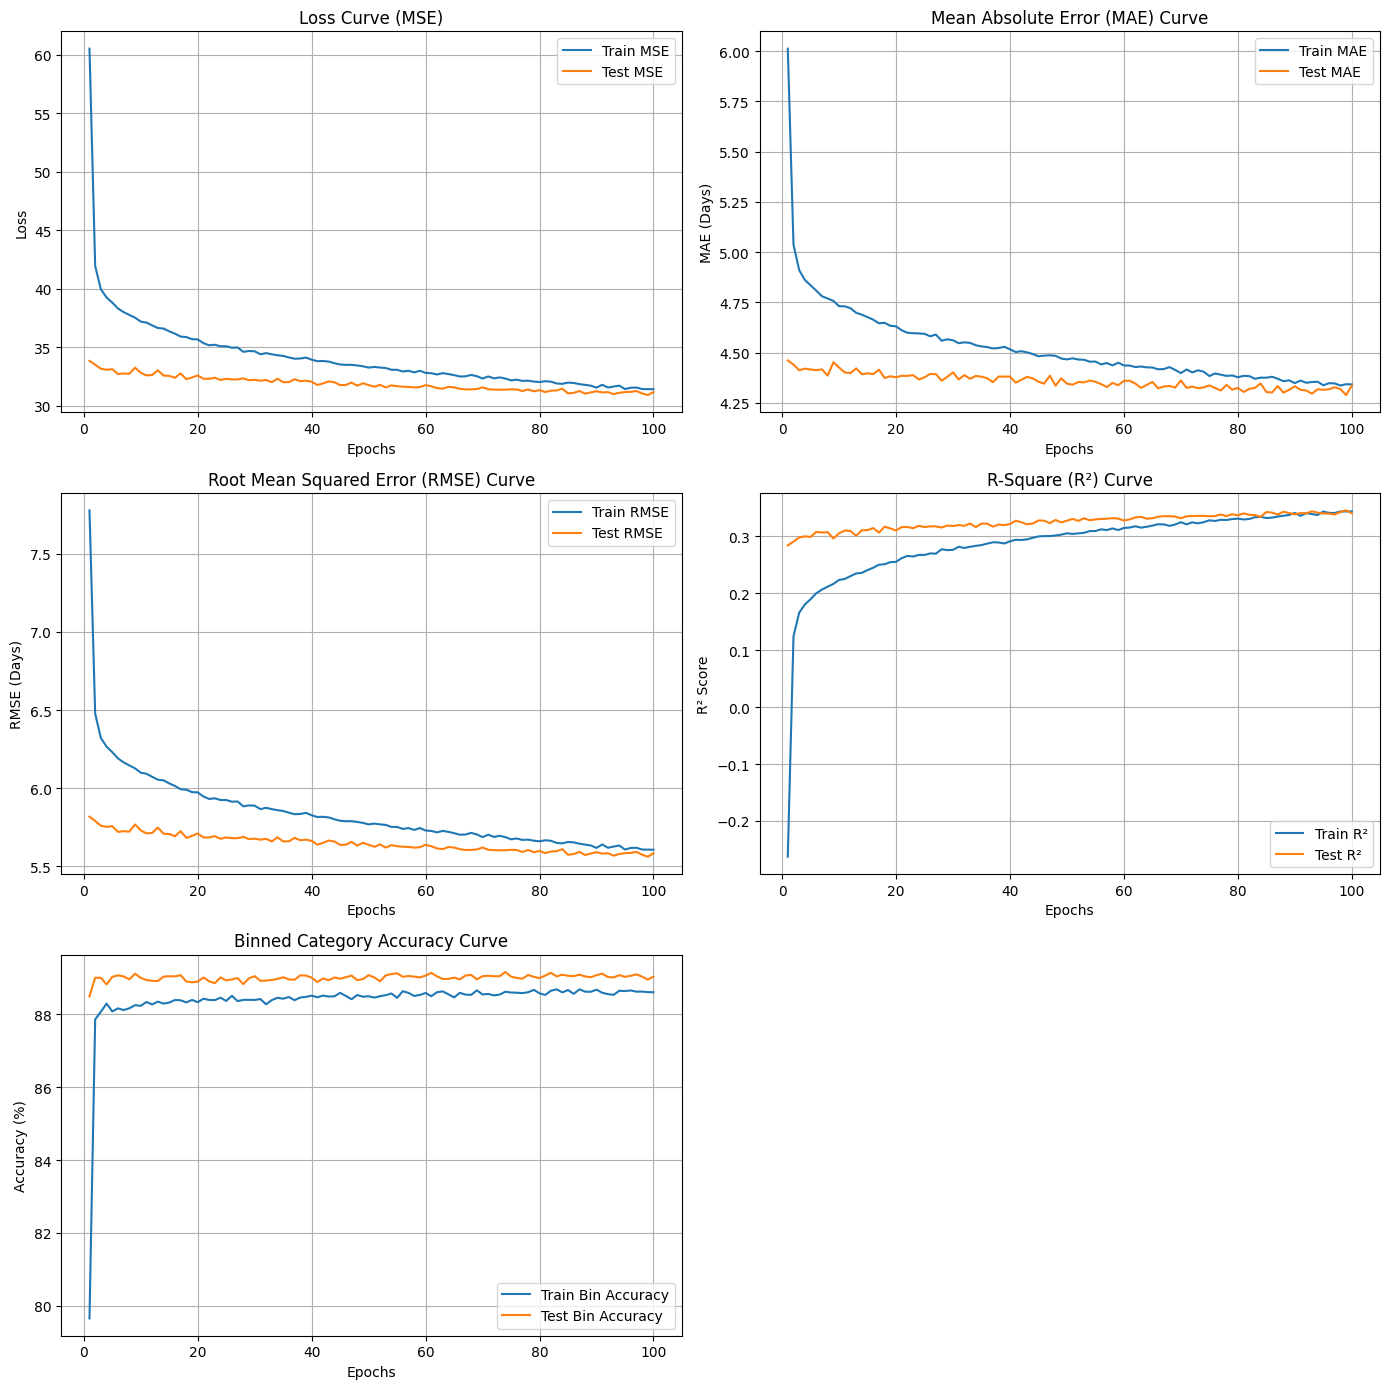

In [108]:
# --- Binning Configurations ---
bins = [-np.inf, -5, 0, 4, np.inf]
labels = ['Very Early', 'Early', 'Late', 'Very Late']

# Training Loop
epochs = 100
history = {
    'train_loss': [], 'test_loss': [],
    'train_mae': [], 'test_mae': [],
    'train_rmse': [], 'test_rmse': [],
    'train_r2': [], 'test_r2': [],
    'train_bin_acc': [], 'test_bin_acc': []  # Added tracking for binned accuracy
}

for epoch in range(epochs):
    model.train()
    all_train_preds = []
    all_train_trues = []
    running_train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * batch_X.size(0)
        all_train_preds.extend(outputs.detach().cpu().numpy().flatten())
        all_train_trues.extend(batch_y.cpu().numpy().flatten())
        
    epoch_train_loss = running_train_loss / len(train_dataset)
    train_mae = mean_absolute_error(all_train_trues, all_train_preds)
    train_rmse = np.sqrt(mean_squared_error(all_train_trues, all_train_preds))
    train_r2 = r2_score(all_train_trues, all_train_preds)
    
    # --- Training Binning Calculations ---
    binned_train_preds = pd.cut(all_train_preds, bins=bins, labels=labels, right=True)
    binned_train_trues = pd.cut(all_train_trues, bins=bins, labels=labels, right=True)
    train_bin_acc = accuracy_score(binned_train_trues, binned_train_preds)
    
    model.eval()
    all_test_preds = []
    all_test_trues = []
    running_test_loss = 0.0
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            running_test_loss += loss.item() * batch_X.size(0)
            all_test_preds.extend(outputs.cpu().numpy().flatten())
            all_test_trues.extend(batch_y.cpu().numpy().flatten())
            
    epoch_test_loss = running_test_loss / len(test_dataset)
    test_mae = mean_absolute_error(all_test_trues, all_test_preds)
    test_rmse = np.sqrt(mean_squared_error(all_test_trues, all_test_preds))
    test_r2 = r2_score(all_test_trues, all_test_preds)
    
    # --- Testing Binning Calculations ---
    binned_test_preds = pd.cut(all_test_preds, bins=bins, labels=labels, right=True)
    binned_test_trues = pd.cut(all_test_trues, bins=bins, labels=labels, right=True)
    test_bin_acc = accuracy_score(binned_test_trues, binned_test_preds)
    
    # --- History Storage ---
    history['train_loss'].append(epoch_train_loss)
    history['test_loss'].append(epoch_test_loss)
    history['train_mae'].append(train_mae)
    history['test_mae'].append(test_mae)
    history['train_rmse'].append(train_rmse)
    history['test_rmse'].append(test_rmse)
    history['train_r2'].append(train_r2)
    history['test_r2'].append(test_r2)
    history['train_bin_acc'].append(train_bin_acc)
    history['test_bin_acc'].append(test_bin_acc)
    
    print(f"Epoch {epoch+1:02d}/{epochs} | "
          f"Train MSE: {epoch_train_loss:.4f} - Test MSE: {epoch_test_loss:.4f} | "
          f"Train Bin Acc: {train_bin_acc*100:.2f}% - Test Bin Acc: {test_bin_acc*100:.2f}%")

# --- 4. Visualization (Updated to 3x2 Grid Layout) ---
fig, axs = plt.subplots(3, 2, figsize=(14, 14))

# MSE Loss Curve
axs[0, 0].plot(range(1, epochs + 1), history['train_loss'], label='Train MSE')
axs[0, 0].plot(range(1, epochs + 1), history['test_loss'], label='Test MSE')
axs[0, 0].set_title('Loss Curve (MSE)')
axs[0, 0].set_xlabel('Epochs')
axs[0, 0].set_ylabel('Loss')
axs[0, 0].legend()
axs[0, 0].grid(True)

# MAE Curve
axs[0, 1].plot(range(1, epochs + 1), history['train_mae'], label='Train MAE')
axs[0, 1].plot(range(1, epochs + 1), history['test_mae'], label='Test MAE')
axs[0, 1].set_title('Mean Absolute Error (MAE) Curve')
axs[0, 1].set_xlabel('Epochs')
axs[0, 1].set_ylabel('MAE (Days)')
axs[0, 1].legend()
axs[0, 1].grid(True)

# RMSE Curve
axs[1, 0].plot(range(1, epochs + 1), history['train_rmse'], label='Train RMSE')
axs[1, 0].plot(range(1, epochs + 1), history['test_rmse'], label='Test RMSE')
axs[1, 0].set_title('Root Mean Squared Error (RMSE) Curve')
axs[1, 0].set_xlabel('Epochs')
axs[1, 0].set_ylabel('RMSE (Days)')
axs[1, 0].legend()
axs[1, 0].grid(True)

# R-Square Curve
axs[1, 1].plot(range(1, epochs + 1), history['train_r2'], label='Train R²')
axs[1, 1].plot(range(1, epochs + 1), history['test_r2'], label='Test R²')
axs[1, 1].set_title('R-Square (R²) Curve')
axs[1, 1].set_xlabel('Epochs')
axs[1, 1].set_ylabel('R² Score')
axs[1, 1].legend()
axs[1, 1].grid(True)

# Binned Classification Accuracy Curve
axs[2, 0].plot(range(1, epochs + 1), [acc * 100 for acc in history['train_bin_acc']], label='Train Bin Accuracy')
axs[2, 0].plot(range(1, epochs + 1), [acc * 100 for acc in history['test_bin_acc']], label='Test Bin Accuracy')
axs[2, 0].set_title('Binned Category Accuracy Curve')
axs[2, 0].set_xlabel('Epochs')
axs[2, 0].set_ylabel('Accuracy (%)')
axs[2, 0].legend()
axs[2, 0].grid(True)

# Hide the empty 6th subplot (row 2, col 1) to keep the layout clean
fig.delaxes(axs[2, 1])

plt.tight_layout()
plt.show()

In [109]:
results_df = pd.DataFrame({
    'Actual_Days': all_test_trues,
    'Predicted_Days': all_test_preds,
    'Actual_Status': binned_test_trues,
    'Predicted_Status': binned_test_preds
})
results_df.to_csv("delivery_predictions.csv", index=False)